# Tema 6 - Circuitos de Corriente Continua

**Teoría de Circuitos - ETSI, Universidad de Sevilla**

---

## Objetivos de aprendizaje

- Distinguir entre régimen transitorio y régimen permanente en circuitos con elementos dinámicos
- Analizar circuitos en régimen permanente de corriente continua (CC) sustituyendo condensadores e inductores por sus equivalentes
- Determinar condiciones iniciales en un instante dado usando la continuidad de $u_C$ e $i_L$
- Resolver circuitos transitorios de primer orden (RC y RL) con la fórmula general de la exponencial
- Descomponer la respuesta en natural (homogénea) y forzada (particular)
- Calcular la constante de tiempo $\tau$ a partir de la resistencia de Thévenin

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - límites, referencias
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados
COLOR_TRANS = '#ff7f00'       # naranja - régimen transitorio
COLOR_PERM = '#6a3d9a'        # púrpura - régimen permanente

print('Configuración lista.')

Configuración lista.


---

## 1. Régimen transitorio vs régimen permanente

Cuando un circuito contiene solo resistencias y fuentes (circuito **estático**), la respuesta a cualquier cambio es instantánea: no hay memoria ni evolución temporal.

Sin embargo, cuando el circuito incluye **condensadores** ($C$) o **inductores** ($L$) — elementos **dinámicos** — la respuesta no es inmediata. Al producirse un cambio (conexión de fuente, apertura de interruptor, etc.), el circuito atraviesa dos fases:

1. **Régimen transitorio**: evolución temporal desde las condiciones iniciales hasta el estado final. La duración depende de la **constante de tiempo** $\tau$ del circuito.
2. **Régimen permanente** (estacionario): estado al que tiende el circuito cuando $t \to \infty$. Todas las magnitudes alcanzan valores constantes (en CC).

**Regla práctica:** el transitorio se considera terminado tras $\approx 5\tau$ (la señal ha alcanzado el 99.3% de su valor final).

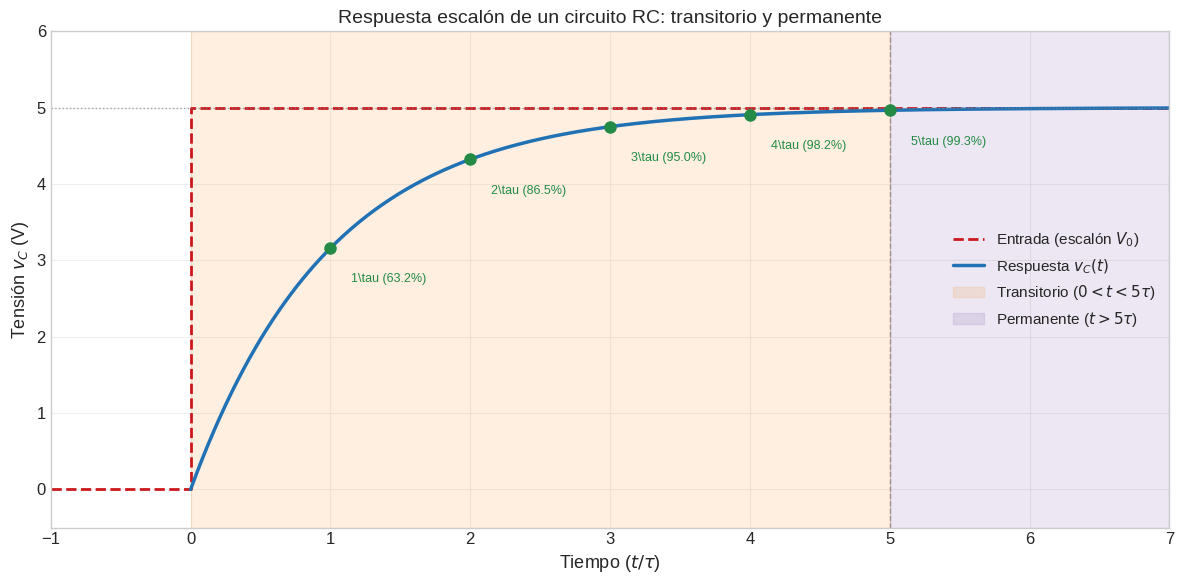

In [2]:
# Respuesta escalón: régimen transitorio + permanente
fig, ax = plt.subplots(figsize=(12, 6))

tau = 1.0
t = np.linspace(0, 7, 500)
v_final = 5.0
v_init = 0.0
v = v_final * (1 - np.exp(-t / tau))

# Señal de entrada (escalón)
t_full = np.concatenate([[-1, 0, 0], t])
v_input = np.concatenate([[0, 0, v_final], np.full_like(t, v_final)])

ax.plot(t_full, v_input, '--', color=COLOR_RECTA, lw=2, label=r'Entrada (escalón $V_0$)')
ax.plot(t, v, color=COLOR_PRINCIPAL, lw=2.5, label=r'Respuesta $v_C(t)$')

# Zona transitoria
ax.axvspan(0, 5*tau, alpha=0.12, color=COLOR_TRANS, label=r'Transitorio ($0 < t < 5\tau$)')
ax.axvspan(5*tau, 7, alpha=0.12, color=COLOR_PERM, label=r'Permanente ($t > 5\tau$)')

# Líneas de referencia
ax.axhline(y=v_final, color='gray', ls=':', lw=1, alpha=0.7)
ax.axvline(x=5*tau, color='gray', ls='--', lw=1, alpha=0.7)

# Marcas de tau
for i in range(1, 6):
    vi = v_final * (1 - np.exp(-i))
    ax.plot(i*tau, vi, 'o', color=COLOR_PUNTO, ms=8, zorder=5)
    pct = (1 - np.exp(-i)) * 100
    ax.annotate(f'{i}\\tau ({pct:.1f}%)', xy=(i*tau, vi),
                xytext=(i*tau + 0.15, vi - 0.45), fontsize=9, color=COLOR_PUNTO)

ax.set_xlabel(r'Tiempo ($t/\tau$)')
ax.set_ylabel(r'Tensión $v_C$ (V)')
ax.set_title('Respuesta escalón de un circuito RC: transitorio y permanente')
ax.set_xlim(-1, 7)
ax.set_ylim(-0.5, 6)
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 2. Régimen permanente de corriente continua (CC)

En **régimen permanente CC**, todas las magnitudes del circuito son constantes: tensiones, corrientes, potencias. Esto implica que **todas las derivadas temporales son cero**.

### Consecuencias para los elementos dinámicos

| Elemento | Ecuación constitutiva | En CC ($\frac{d}{dt} = 0$) | Equivalente |
|----------|----------------------|---------------------------|-------------|
| **Condensador** | $i_C = C \dfrac{du_C}{dt}$ | $i_C = C \cdot 0 = 0$ | **Circuito abierto** (no pasa corriente) |
| **Inductor** | $u_L = L \dfrac{di_L}{dt}$ | $u_L = L \cdot 0 = 0$ | **Cortocircuito** (no cae tensión) |

### Metodología: análisis en régimen permanente CC

1. **Sustituir** cada condensador por un **circuito abierto** (eliminar la rama)
2. **Sustituir** cada inductor por un **cortocircuito** (reemplazar por cable)
3. **Resolver** el circuito resistivo resultante con las técnicas habituales (nudos, mallas, Thévenin...)

$$\boxed{\text{CC permanente:} \quad C \to \text{abierto} \quad L \to \text{cortocircuito}}$$

> **Error frecuente:** Confundir los equivalentes. Recuerda: el condensador **bloquea** la CC (abierto), el inductor **deja pasar** la CC (corto).

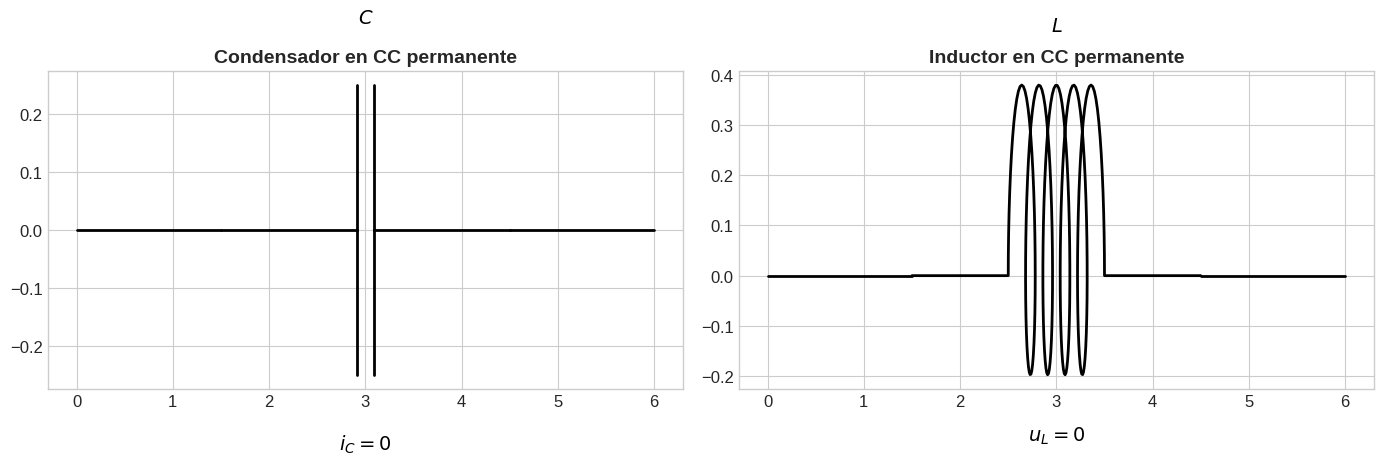

In [3]:
# Diagrama: equivalentes en CC permanente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Condensador -> abierto
ax = axes[0]
ax.set_title('Condensador en CC permanente', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Line().right().length(1.5)
d += elm.Capacitor().right().label(r'$C$', loc='top').label(r'$i_C = 0$', loc='bottom')
d += elm.Line().right().length(1.5)
d.draw()

# Inductor -> corto
ax = axes[1]
ax.set_title('Inductor en CC permanente', fontsize=14, fontweight='bold')
d2 = schemdraw.Drawing(canvas=ax)
d2 += elm.Line().right().length(1.5)
d2 += elm.Inductor2().right().label(r'$L$', loc='top').label(r'$u_L = 0$', loc='bottom')
d2 += elm.Line().right().length(1.5)
d2.draw()

plt.tight_layout()
plt.show()

---

## 3. Circuitos dinámicos en un instante dado

En muchos problemas se pide calcular magnitudes del circuito **en un instante concreto** $t = t_0$, conociendo las condiciones de los elementos dinámicos en ese instante.

### Principio de continuidad

Las variables de **estado** no pueden cambiar instantáneamente (requieren energía infinita):

$$\boxed{u_C(t_0^+) = u_C(t_0^-)} \qquad \boxed{i_L(t_0^+) = i_L(t_0^-)}$$

- La **tensión en el condensador** es continua $\to$ en $t = t_0$ el condensador se comporta como una **fuente de tensión** de valor $u_C(t_0)$
- La **corriente en el inductor** es continua $\to$ en $t = t_0$ el inductor se comporta como una **fuente de corriente** de valor $i_L(t_0)$

### Metodología: análisis en un instante $t_0$

1. Determinar $u_C(t_0)$ e $i_L(t_0)$ (datos del problema o calculados del régimen permanente previo)
2. **Sustituir** cada condensador por una **fuente de tensión** $u_C(t_0)$
3. **Sustituir** cada inductor por una **fuente de corriente** $i_L(t_0)$
4. **Resolver** el circuito resultante (resistivo con fuentes) para obtener cualquier otra variable

> **Truco para el examen:** Si el circuito estaba en régimen permanente CC antes de $t_0$, calcula primero $u_C$ e $i_L$ con el método de la sección 2 (condensador abierto, inductor corto) y luego usa esos valores como condiciones iniciales.

---

## 4. Régimen transitorio de primer orden (RC y RL)

Los circuitos de **primer orden** contienen un único elemento dinámico (un $C$ o un $L$) junto con resistencias y fuentes. Su respuesta transitoria es siempre una **exponencial**.

### 4.1 Fórmula general

$$\boxed{x(t) = x(\infty) + \left[x(0^+) - x(\infty)\right] \cdot e^{-t/\tau}}$$

donde $x(t)$ es cualquier tensión o corriente del circuito, y los tres valores a determinar son:

| Paso | Qué calcular | Cómo |
|------|-------------|------|
| 1. $x(0^+)$ | **Valor inicial** justo después del cambio | Usar continuidad ($u_C$ o $i_L$) + resolver circuito en $t = 0^+$ |
| 2. $x(\infty)$ | **Valor final** en régimen permanente | Resolver circuito en CC permanente ($C$ abierto, $L$ corto) |
| 3. $\tau$ | **Constante de tiempo** | $\tau = R_{Th} \cdot C$ (RC) o $\tau = L / R_{Th}$ (RL) |

### 4.2 Circuito RC

$$\boxed{\tau_{RC} = R_{Th} \cdot C}$$

$$v_C(t) = v_C(\infty) + \left[v_C(0^+) - v_C(\infty)\right] \cdot e^{-t/\tau}$$

- **Carga** (de 0 a $V_0$): $v_C(t) = V_0 \left(1 - e^{-t/\tau}\right)$
- **Descarga** (de $V_0$ a 0): $v_C(t) = V_0 \cdot e^{-t/\tau}$

### 4.3 Circuito RL

$$\boxed{\tau_{RL} = \frac{L}{R_{Th}}}$$

$$i_L(t) = i_L(\infty) + \left[i_L(0^+) - i_L(\infty)\right] \cdot e^{-t/\tau}$$

- **Energización** (de 0 a $I_0$): $i_L(t) = I_0 \left(1 - e^{-t/\tau}\right)$
- **Desenergización** (de $I_0$ a 0): $i_L(t) = I_0 \cdot e^{-t/\tau}$

### 4.4 Cálculo de $R_{Th}$

Para encontrar $\tau$, necesitamos la **resistencia de Thévenin** vista desde los terminales del elemento dinámico:

1. **Apagar** todas las fuentes independientes (tensión $\to$ cortocircuito, corriente $\to$ circuito abierto)
2. **Retirar** el condensador o inductor
3. **Calcular** $R_{Th}$ entre los terminales donde estaba el elemento

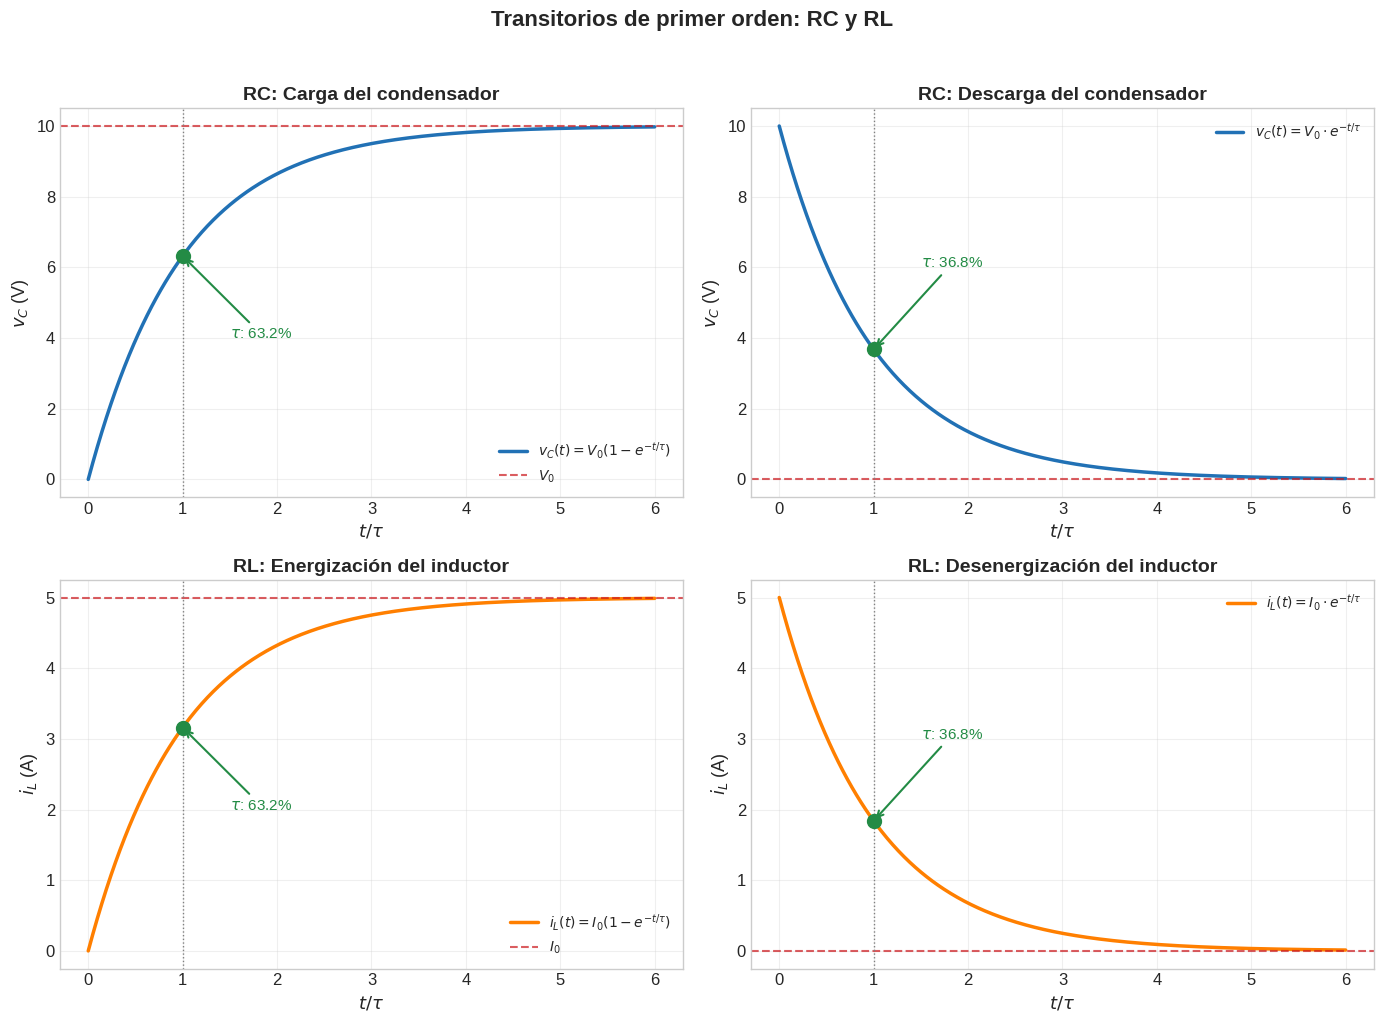

In [4]:
# Gráficas: carga/descarga RC y energización/desenergización RL
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tau = 1.0
t = np.linspace(0, 6, 500)
V0 = 10.0
I0 = 5.0

# RC Carga
ax = axes[0, 0]
vc_carga = V0 * (1 - np.exp(-t / tau))
ax.plot(t, vc_carga, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t) = V_0(1 - e^{-t/\tau})$')
ax.axhline(y=V0, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7, label=r'$V_0$')
ax.axvline(x=tau, color='gray', ls=':', lw=1)
ax.plot(tau, V0*(1-np.exp(-1)), 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(r'$\tau$: 63.2%', xy=(tau, V0*(1-np.exp(-1))),
            xytext=(tau+0.5, V0*0.4), fontsize=11, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))
ax.set_title('RC: Carga del condensador', fontweight='bold')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$v_C$ (V)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# RC Descarga
ax = axes[0, 1]
vc_desc = V0 * np.exp(-t / tau)
ax.plot(t, vc_desc, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t) = V_0 \cdot e^{-t/\tau}$')
ax.axhline(y=0, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7)
ax.axvline(x=tau, color='gray', ls=':', lw=1)
ax.plot(tau, V0*np.exp(-1), 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(r'$\tau$: 36.8%', xy=(tau, V0*np.exp(-1)),
            xytext=(tau+0.5, V0*0.6), fontsize=11, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))
ax.set_title('RC: Descarga del condensador', fontweight='bold')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$v_C$ (V)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# RL Energización
ax = axes[1, 0]
il_energ = I0 * (1 - np.exp(-t / tau))
ax.plot(t, il_energ, color=COLOR_TRANS, lw=2.5, label=r'$i_L(t) = I_0(1 - e^{-t/\tau})$')
ax.axhline(y=I0, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7, label=r'$I_0$')
ax.axvline(x=tau, color='gray', ls=':', lw=1)
ax.plot(tau, I0*(1-np.exp(-1)), 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(r'$\tau$: 63.2%', xy=(tau, I0*(1-np.exp(-1))),
            xytext=(tau+0.5, I0*0.4), fontsize=11, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))
ax.set_title('RL: Energización del inductor', fontweight='bold')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$i_L$ (A)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# RL Desenergización
ax = axes[1, 1]
il_des = I0 * np.exp(-t / tau)
ax.plot(t, il_des, color=COLOR_TRANS, lw=2.5, label=r'$i_L(t) = I_0 \cdot e^{-t/\tau}$')
ax.axhline(y=0, color=COLOR_RECTA, ls='--', lw=1.5, alpha=0.7)
ax.axvline(x=tau, color='gray', ls=':', lw=1)
ax.plot(tau, I0*np.exp(-1), 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(r'$\tau$: 36.8%', xy=(tau, I0*np.exp(-1)),
            xytext=(tau+0.5, I0*0.6), fontsize=11, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))
ax.set_title('RL: Desenergización del inductor', fontweight='bold')
ax.set_xlabel(r'$t/\tau$')
ax.set_ylabel(r'$i_L$ (A)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Transitorios de primer orden: RC y RL', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Respuesta natural y respuesta forzada

La respuesta total de un circuito de primer orden se puede descomponer en dos partes:

$$\boxed{x(t) = x_{\text{natural}}(t) + x_{\text{forzada}}(t)}$$

### Respuesta natural (homogénea)

Es la solución de la ecuación diferencial **sin fuentes** (homogénea). Representa cómo el circuito libera o absorbe la energía almacenada inicialmente.

$$x_{\text{natural}}(t) = K \cdot e^{-t/\tau}$$

- Siempre es una **exponencial decreciente** (para circuitos estables)
- Tiende a cero cuando $t \to \infty$
- La constante $K$ se determina con las condiciones iniciales

### Respuesta forzada (particular)

Es la solución **particular** debida a las fuentes externas. En CC, es simplemente el valor de régimen permanente:

$$x_{\text{forzada}}(t) = x(\infty) \quad \text{(constante para fuentes CC)}$$

### Conexión con la fórmula general

$$x(t) = \underbrace{x(\infty)}_{\text{forzada}} + \underbrace{\left[x(0^+) - x(\infty)\right] \cdot e^{-t/\tau}}_{\text{natural}}$$

La constante $K = x(0^+) - x(\infty)$ se ajusta para que en $t = 0^+$ la suma dé exactamente $x(0^+)$.

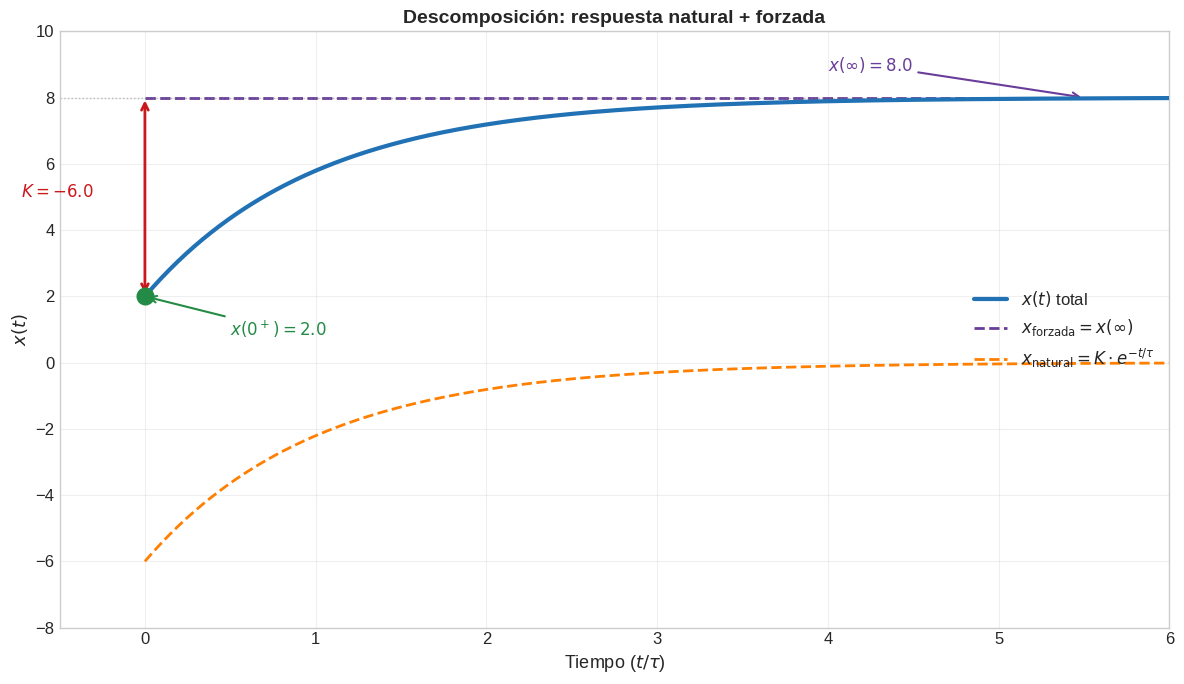

In [5]:
# Descomposición: natural + forzada
fig, ax = plt.subplots(figsize=(12, 7))

tau = 1.0
t = np.linspace(0, 6, 500)
x_0 = 2.0    # valor inicial
x_inf = 8.0  # valor final (forzada)

# Componentes
x_forzada = np.full_like(t, x_inf)
K = x_0 - x_inf  # = -6
x_natural = K * np.exp(-t / tau)
x_total = x_forzada + x_natural

ax.plot(t, x_total, color=COLOR_PRINCIPAL, lw=3, label=r'$x(t)$ total', zorder=4)
ax.plot(t, x_forzada, '--', color=COLOR_PERM, lw=2, label=r'$x_{\mathrm{forzada}} = x(\infty)$')
ax.plot(t, x_natural, '--', color=COLOR_TRANS, lw=2, label=r'$x_{\mathrm{natural}} = K \cdot e^{-t/\tau}$')

# Puntos clave
ax.plot(0, x_0, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.annotate(f'$x(0^+) = {x_0}$', xy=(0, x_0), xytext=(0.5, x_0 - 1.2),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

ax.axhline(y=x_inf, color='gray', ls=':', lw=1, alpha=0.5)
ax.annotate(f'$x(\\infty) = {x_inf}$', xy=(5.5, x_inf), fontsize=12,
            color=COLOR_PERM, fontweight='bold',
            xytext=(4, x_inf + 0.8),
            arrowprops=dict(arrowstyle='->', color=COLOR_PERM, lw=1.5))

# Flecha K
ax.annotate('', xy=(0, x_inf), xycoords='data',
            xytext=(0, x_0), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color=COLOR_RECTA, lw=2))
ax.text(-0.3, (x_0 + x_inf) / 2, f'$K = {K}$', fontsize=12, color=COLOR_RECTA,
        fontweight='bold', ha='right')

ax.set_xlabel(r'Tiempo ($t/\tau$)')
ax.set_ylabel(r'$x(t)$')
ax.set_title('Descomposición: respuesta natural + forzada', fontweight='bold')
ax.legend(fontsize=12, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 6)
ax.set_ylim(-8, 10)
plt.tight_layout()
plt.show()

---

## 6. Ejercicios resueltos

### 6.1 Ejercicio resuelto: Carga RC desde 0 V

#### Ejercicio resuelto: Circuito RC — Carga desde condensador descargado

**Datos:** $V_S = 10$ V, $R = 5\;\text{k}\Omega$, $C = 2\;\mu\text{F}$, $v_C(0^-) = 0$ V. En $t = 0$ se cierra el interruptor.

**Paso 1:** Valor inicial $v_C(0^+)$

Por continuidad: $v_C(0^+) = v_C(0^-) = 0$ V

**Paso 2:** Valor final $v_C(\infty)$

En CC permanente, $C$ es circuito abierto $\to$ no circula corriente $\to$ no cae tensión en $R$:

$$v_C(\infty) = V_S = 10\;\text{V}$$

**Paso 3:** Constante de tiempo

$$\tau = R \cdot C = 5\;\text{k}\Omega \times 2\;\mu\text{F} = 10\;\text{ms}$$

**Resultado:**

$$\boxed{v_C(t) = 10\left(1 - e^{-t/10\text{ms}}\right)\;\text{V}}$$

La corriente por el circuito:

$$i(t) = C\frac{dv_C}{dt} = \frac{V_S}{R}e^{-t/\tau} = \frac{10}{5\text{k}} \cdot e^{-t/10\text{ms}} = 2\;\text{mA} \cdot e^{-t/10\text{ms}}$$

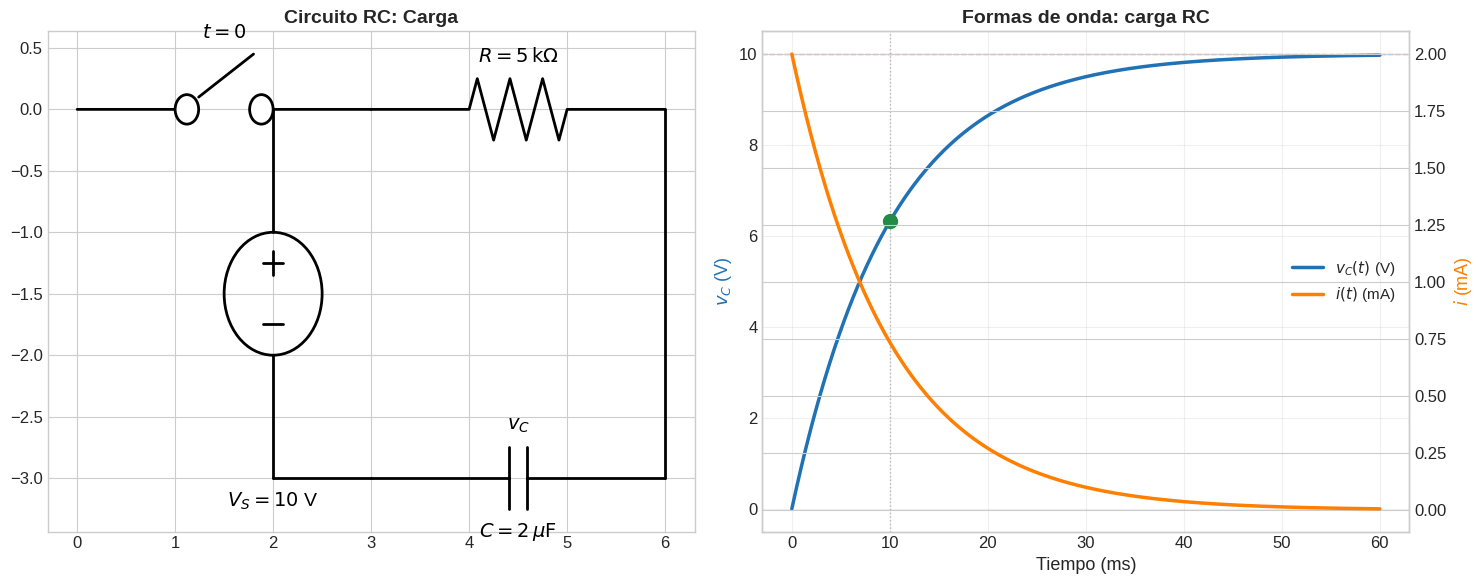

In [6]:
# Ejercicio 6.1: Circuito RC carga — diagrama + forma de onda
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Diagrama del circuito
ax = axes[0]
ax.set_title('Circuito RC: Carga', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += (sw := elm.Switch().right().label('$t=0$', loc='top'))
d += elm.Resistor().right().label(r'$R = 5\,\mathrm{k\Omega}$', loc='top')
d += elm.Line().down().length(3)
d += elm.Capacitor().left().label(r'$C = 2\,\mu\mathrm{F}$', loc='bottom').label(r'$v_C$', loc='top')
d += elm.Line().left().length(1)
d += elm.SourceV().up().label(r'$V_S = 10$ V', loc='left')
d.draw()

# Forma de onda
ax = axes[1]
tau_ms = 10.0  # ms
t_ms = np.linspace(0, 60, 500)
vc = 10 * (1 - np.exp(-t_ms / tau_ms))
ic = 2 * np.exp(-t_ms / tau_ms)

ax.plot(t_ms, vc, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t)$ (V)')
ax2 = ax.twinx()
ax2.plot(t_ms, ic, color=COLOR_TRANS, lw=2.5, label=r'$i(t)$ (mA)')

ax.axhline(y=10, color=COLOR_RECTA, ls='--', lw=1, alpha=0.5)
ax.axvline(x=tau_ms, color='gray', ls=':', lw=1, alpha=0.5)
ax.plot(tau_ms, 10*(1-np.exp(-1)), 'o', color=COLOR_PUNTO, ms=10, zorder=5)

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$v_C$ (V)', color=COLOR_PRINCIPAL)
ax2.set_ylabel(r'$i$ (mA)', color=COLOR_TRANS)
ax.set_title('Formas de onda: carga RC', fontweight='bold')

# Leyenda combinada
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Ejercicio resuelto: Descarga RC

#### Ejercicio resuelto: Circuito RC — Descarga

**Datos:** $R = 10\;\text{k}\Omega$, $C = 1\;\mu\text{F}$, $v_C(0^-) = 12$ V. En $t = 0$ se cierra el interruptor y el condensador se descarga a través de $R$ (sin fuente).

**Paso 1:** Valor inicial

$$v_C(0^+) = v_C(0^-) = 12\;\text{V}$$

**Paso 2:** Valor final

Sin fuente: $v_C(\infty) = 0$ V

**Paso 3:** Constante de tiempo

$$\tau = R \cdot C = 10\;\text{k}\Omega \times 1\;\mu\text{F} = 10\;\text{ms}$$

**Resultado:**

$$\boxed{v_C(t) = 12 \cdot e^{-t/10\text{ms}}\;\text{V}}$$

**Corriente:** (sale del condensador, signo negativo por convención)

$$i(t) = -\frac{v_C(0^+)}{R} \cdot e^{-t/\tau} = -\frac{12}{10\text{k}} \cdot e^{-t/10\text{ms}} = -1.2\;\text{mA} \cdot e^{-t/10\text{ms}}$$

**Energía disipada** en la resistencia (igual a la energía inicial del condensador):

$$W = \frac{1}{2}C \cdot v_C^2(0) = \frac{1}{2} \times 1\;\mu\text{F} \times 12^2 = 72\;\mu\text{J}$$

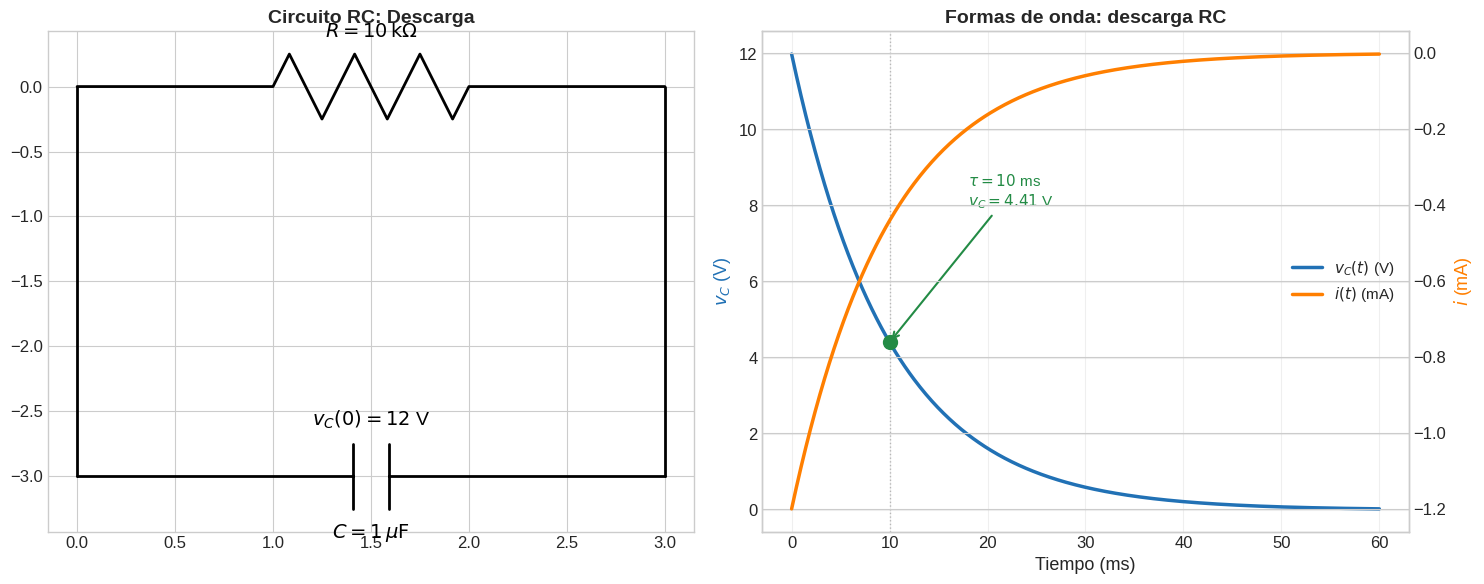

In [7]:
# Ejercicio 6.2: Circuito RC descarga — diagrama + forma de onda
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Diagrama del circuito
ax = axes[0]
ax.set_title('Circuito RC: Descarga', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Resistor().right().label(r'$R = 10\,\mathrm{k\Omega}$', loc='top')
d += elm.Line().down().length(3)
d += elm.Capacitor().left().label(r'$C = 1\,\mu\mathrm{F}$', loc='bottom').label(r'$v_C(0)=12$ V', loc='top')
d += elm.Line().up().length(3)
d.draw()

# Forma de onda
ax = axes[1]
tau_ms = 10.0
t_ms = np.linspace(0, 60, 500)
vc = 12 * np.exp(-t_ms / tau_ms)
ic = -1.2 * np.exp(-t_ms / tau_ms)

ax.plot(t_ms, vc, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t)$ (V)')
ax2 = ax.twinx()
ax2.plot(t_ms, ic, color=COLOR_TRANS, lw=2.5, label=r'$i(t)$ (mA)')

ax.axvline(x=tau_ms, color='gray', ls=':', lw=1, alpha=0.5)
ax.plot(tau_ms, 12*np.exp(-1), 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(f'$\\tau = {tau_ms:.0f}$ ms\n$v_C = {12*np.exp(-1):.2f}$ V',
            xy=(tau_ms, 12*np.exp(-1)), xytext=(tau_ms+8, 8),
            fontsize=11, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$v_C$ (V)', color=COLOR_PRINCIPAL)
ax2.set_ylabel(r'$i$ (mA)', color=COLOR_TRANS)
ax.set_title('Formas de onda: descarga RC', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Ejercicio resuelto: Energización RL

#### Ejercicio resuelto: Circuito RL — Energización del inductor

**Datos:** $V_S = 24$ V, $R = 8\;\Omega$, $L = 0.4\;\text{H}$, $i_L(0^-) = 0$ A. En $t = 0$ se cierra el interruptor.

**Paso 1:** Valor inicial

$$i_L(0^+) = i_L(0^-) = 0\;\text{A}$$

**Paso 2:** Valor final

En CC permanente, $L$ es cortocircuito:

$$i_L(\infty) = \frac{V_S}{R} = \frac{24}{8} = 3\;\text{A}$$

**Paso 3:** Constante de tiempo

$$\tau = \frac{L}{R} = \frac{0.4}{8} = 50\;\text{ms}$$

**Resultado:**

$$\boxed{i_L(t) = 3\left(1 - e^{-t/50\text{ms}}\right)\;\text{A}}$$

**Tensión en el inductor:**

$$u_L(t) = L\frac{di_L}{dt} = V_S \cdot e^{-t/\tau} = 24 \cdot e^{-t/50\text{ms}}\;\text{V}$$

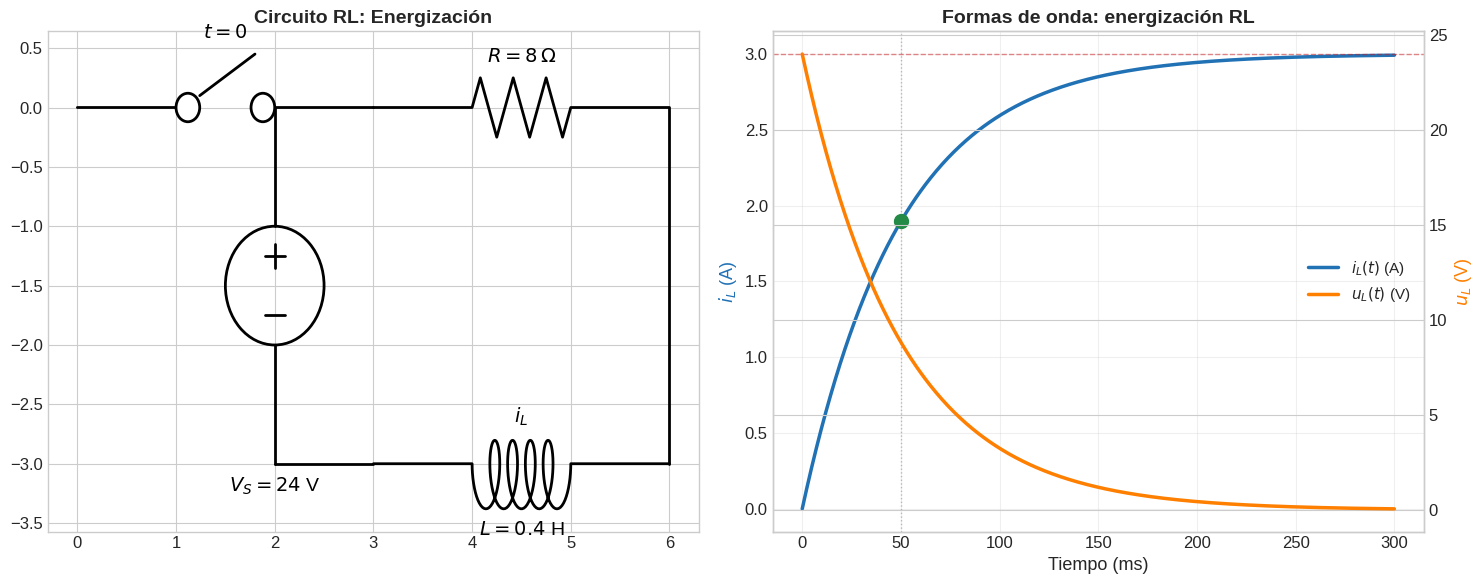

In [8]:
# Ejercicio 6.3: Circuito RL energización — diagrama + forma de onda
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Diagrama del circuito
ax = axes[0]
ax.set_title('Circuito RL: Energización', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += (sw := elm.Switch().right().label('$t=0$', loc='top'))
d += elm.Resistor().right().label(r'$R = 8\,\Omega$', loc='top')
d += elm.Line().down().length(3)
d += elm.Inductor2().left().label(r'$L = 0.4$ H', loc='bottom').label(r'$i_L$', loc='top')
d += elm.Line().left().length(1)
d += elm.SourceV().up().label(r'$V_S = 24$ V', loc='left')
d.draw()

# Forma de onda
ax = axes[1]
tau_ms = 50.0
t_ms = np.linspace(0, 300, 500)
il = 3 * (1 - np.exp(-t_ms / tau_ms))
ul = 24 * np.exp(-t_ms / tau_ms)

ax.plot(t_ms, il, color=COLOR_PRINCIPAL, lw=2.5, label=r'$i_L(t)$ (A)')
ax2 = ax.twinx()
ax2.plot(t_ms, ul, color=COLOR_TRANS, lw=2.5, label=r'$u_L(t)$ (V)')

ax.axhline(y=3, color=COLOR_RECTA, ls='--', lw=1, alpha=0.5)
ax.axvline(x=tau_ms, color='gray', ls=':', lw=1, alpha=0.5)
ax.plot(tau_ms, 3*(1-np.exp(-1)), 'o', color=COLOR_PUNTO, ms=10, zorder=5)

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$i_L$ (A)', color=COLOR_PRINCIPAL)
ax2.set_ylabel(r'$u_L$ (V)', color=COLOR_TRANS)
ax.set_title('Formas de onda: energización RL', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Ejercicio resuelto: Desenergización RL

#### Ejercicio resuelto: Circuito RL — Desenergización

**Datos:** $R = 100\;\Omega$, $L = 0.5\;\text{H}$, $i_L(0^-) = 2$ A. En $t = 0$ se desconecta la fuente y el inductor se descarga a través de $R$.

**Paso 1:** Valor inicial

$$i_L(0^+) = i_L(0^-) = 2\;\text{A}$$

**Paso 2:** Valor final

Sin fuente: $i_L(\infty) = 0$ A

**Paso 3:** Constante de tiempo

$$\tau = \frac{L}{R} = \frac{0.5}{100} = 5\;\text{ms}$$

**Resultado:**

$$\boxed{i_L(t) = 2 \cdot e^{-t/5\text{ms}}\;\text{A}}$$

**Tensión en el inductor** (pico negativo en $t = 0^+$):

$$u_L(t) = L\frac{di_L}{dt} = -\frac{L \cdot i_L(0^+)}{\tau} \cdot e^{-t/\tau} = -R \cdot i_L(0^+) \cdot e^{-t/\tau} = -200 \cdot e^{-t/5\text{ms}}\;\text{V}$$

> **Nota importante:** La tensión en el inductor puede ser muy grande si $R$ es grande (o si se abre el circuito abruptamente). Esto explica las **chispas** al desconectar circuitos inductivos.

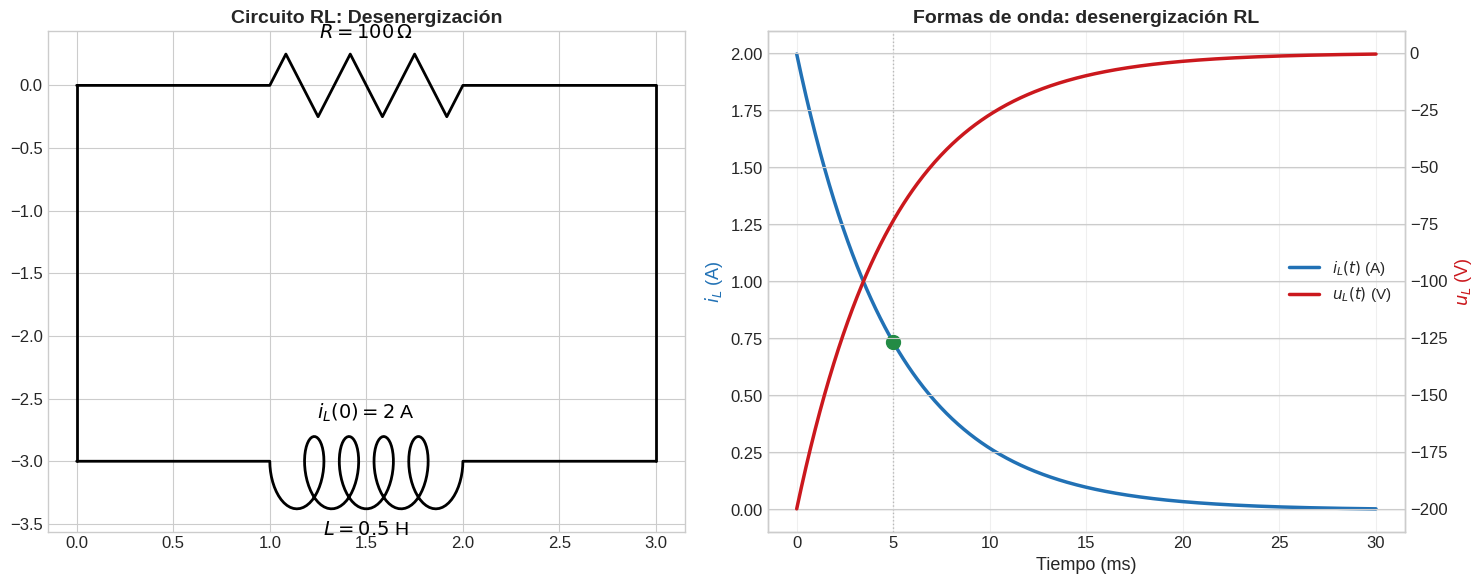

In [9]:
# Ejercicio 6.4: RL desenergización — diagrama + forma de onda
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Diagrama del circuito
ax = axes[0]
ax.set_title('Circuito RL: Desenergización', fontsize=14, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.Resistor().right().label(r'$R = 100\,\Omega$', loc='top')
d += elm.Line().down().length(3)
d += elm.Inductor2().left().label(r'$L = 0.5$ H', loc='bottom').label(r'$i_L(0)=2$ A', loc='top')
d += elm.Line().up().length(3)
d.draw()

# Forma de onda
ax = axes[1]
tau_ms = 5.0
t_ms = np.linspace(0, 30, 500)
il = 2 * np.exp(-t_ms / tau_ms)
ul = -200 * np.exp(-t_ms / tau_ms)

ax.plot(t_ms, il, color=COLOR_PRINCIPAL, lw=2.5, label=r'$i_L(t)$ (A)')
ax2 = ax.twinx()
ax2.plot(t_ms, ul, color=COLOR_RECTA, lw=2.5, label=r'$u_L(t)$ (V)')

ax.axvline(x=tau_ms, color='gray', ls=':', lw=1, alpha=0.5)
ax.plot(tau_ms, 2*np.exp(-1), 'o', color=COLOR_PUNTO, ms=10, zorder=5)

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$i_L$ (A)', color=COLOR_PRINCIPAL)
ax2.set_ylabel(r'$u_L$ (V)', color=COLOR_RECTA)
ax.set_title('Formas de onda: desenergización RL', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5 Ejercicio resuelto: Circuito RC con interruptor que cambia de posición

#### Ejercicio resuelto: RC con cambio de interruptor

**Datos:** $V_1 = 6$ V, $V_2 = 15$ V, $R_1 = 2\;\text{k}\Omega$, $R_2 = 3\;\text{k}\Omega$, $C = 10\;\mu\text{F}$. El interruptor estaba en posición 1 desde hace mucho tiempo. En $t = 0$ cambia a posición 2.

**Antes de $t = 0$** (régimen permanente con $V_1$, $R_1$, $C$):

$C$ abierto $\to$ $i = 0$ $\to$ no cae tensión en $R_1$:

$$v_C(0^-) = V_1 = 6\;\text{V}$$

**Paso 1:** Valor inicial ($t = 0^+$)

$$v_C(0^+) = v_C(0^-) = 6\;\text{V}$$

**Paso 2:** Valor final (régimen permanente con $V_2$, $R_2$, $C$)

$C$ abierto $\to$ $v_C(\infty) = V_2 = 15\;\text{V}$

**Paso 3:** Constante de tiempo (ahora el circuito tiene $R_2$ y $C$)

$$\tau = R_2 \cdot C = 3\;\text{k}\Omega \times 10\;\mu\text{F} = 30\;\text{ms}$$

**Resultado:**

$$\boxed{v_C(t) = 15 + (6 - 15) \cdot e^{-t/30\text{ms}} = 15 - 9 \cdot e^{-t/30\text{ms}}\;\text{V}}$$

**Verificación:** $v_C(0^+) = 15 - 9 = 6$ V $\checkmark$ y $v_C(\infty) = 15$ V $\checkmark$

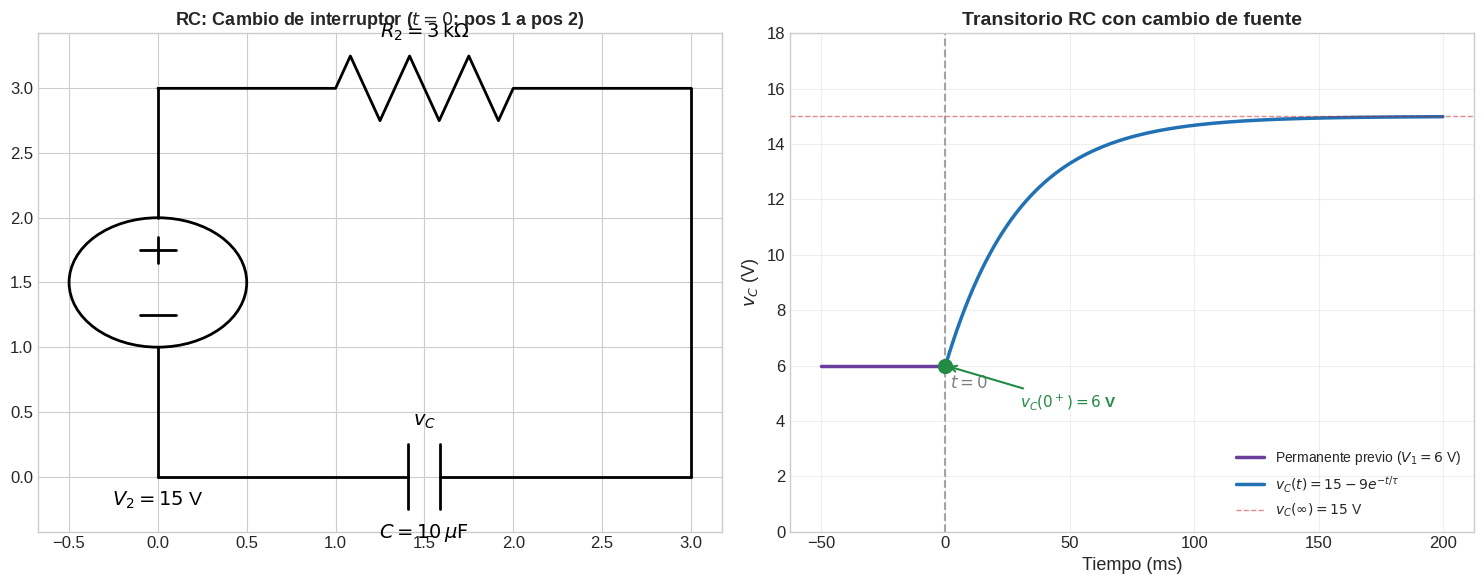

In [10]:
# Ejercicio 6.5: RC con cambio de interruptor — diagrama + forma de onda
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Diagrama del circuito (posición 2)
ax = axes[0]
ax.set_title('RC: Cambio de interruptor ($t=0$: pos 1 a pos 2)', fontsize=13, fontweight='bold')
d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_2 = 15$ V', loc='left')
d += elm.Resistor().right().label(r'$R_2 = 3\,\mathrm{k\Omega}$', loc='top')
d += elm.Line().down().length(3)
d += elm.Capacitor().left().label(r'$C = 10\,\mu\mathrm{F}$', loc='bottom').label(r'$v_C$', loc='top')
d.draw()

# Forma de onda (incluyendo antes de t=0)
ax = axes[1]
tau_ms = 30.0
t_before = np.linspace(-50, 0, 100)
t_after = np.linspace(0, 200, 500)

vc_before = np.full_like(t_before, 6.0)
vc_after = 15 - 9 * np.exp(-t_after / tau_ms)

ax.plot(t_before, vc_before, color=COLOR_PERM, lw=2.5, label=r'Permanente previo ($V_1 = 6$ V)')
ax.plot(t_after, vc_after, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t) = 15 - 9e^{-t/\tau}$')
ax.axhline(y=15, color=COLOR_RECTA, ls='--', lw=1, alpha=0.5, label=r'$v_C(\infty) = 15$ V')
ax.axvline(x=0, color='gray', ls='--', lw=1.5, alpha=0.7)
ax.text(2, 5.2, r'$t = 0$', fontsize=12, color='gray')

ax.plot(0, 6, 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(r'$v_C(0^+) = 6$ V', xy=(0, 6), xytext=(30, 4.5),
            fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$v_C$ (V)')
ax.set_title('Transitorio RC con cambio de fuente', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 18)

plt.tight_layout()
plt.show()

---

## 7. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica todos los tipos de problemas de circuitos de corriente continua que pueden aparecer en exámenes.

| # | Tipo | Elementos | Ecuación clave | Dificultad |
|---|------|-----------|---------------|------------|
| 1 | Régimen permanente CC | $R$, $C$, $L$, fuentes | $C \to$ abierto, $L \to$ corto | Baja |
| 2 | Condiciones iniciales (continuidad) | $C$ o $L$ + interruptor | $v_C(0^+) = v_C(0^-)$, $i_L(0^+) = i_L(0^-)$ | Baja |
| 3 | Transitorio RC: carga | $R$, $C$, fuente CC | $v_C(t) = V_S(1-e^{-t/\tau})$, $\tau = RC$ | Media |
| 4 | Transitorio RC: descarga | $R$, $C$ (sin fuente) | $v_C(t) = V_0 \cdot e^{-t/\tau}$ | Media |
| 5 | Transitorio RL: energización | $R$, $L$, fuente CC | $i_L(t) = I_0(1-e^{-t/\tau})$, $\tau = L/R$ | Media |
| 6 | Transitorio RL: desenergización | $R$, $L$ (sin fuente) | $i_L(t) = I_0 \cdot e^{-t/\tau}$ | Media |
| 7 | Interruptor que cambia posición | $R$'s, $C$ o $L$, fuentes | Fórmula general con $x(0^+)$, $x(\infty)$, $\tau$ | Alta |
| 8 | Cálculo de $\tau$ con Thévenin | Circuito complejo + $C$ o $L$ | $R_{Th}$ vista desde $C$ o $L$ | Alta |
| 9 | Transitorio multi-etapa | $R$'s, $C$ o $L$, 2+ cambios | Resolver cada etapa secuencialmente | Alta |
| 10 | Energía en $C$/$L$ durante transitorio | $C$ o $L$ + $R$'s | $W_C = \frac{1}{2}Cv^2$, $W_L = \frac{1}{2}Li^2$ | Media |

### 7.1 Tipo 1: Régimen permanente CC

Dado un circuito con $R$, $C$, $L$ y fuentes CC, calcular tensiones y corrientes en régimen permanente.

$$\boxed{C \to \text{circuito abierto}} \qquad \boxed{L \to \text{cortocircuito}}$$

**Cómo afectan los componentes:**
- Si hay **más condensadores** $\to$ más ramas se eliminan $\to$ circuito más simple
- Si hay **más inductores** $\to$ más cortocircuitos $\to$ puede anular ramas paralelas
- Las **resistencias en serie con $C$** no afectan (la corriente por esa rama es 0)
- Las **resistencias en serie con $L$** sí importan (corriente circula por el cortocircuito)

#### Ejercicio resuelto: Régimen permanente CC

**Datos:** $V_S = 20$ V, $R_1 = 4\;\text{k}\Omega$, $R_2 = 6\;\text{k}\Omega$, $C = 5\;\mu\text{F}$, $L = 100\;\text{mH}$. El condensador está en serie con $R_2$, y el inductor está en paralelo con $R_2$ (y $C$).

**Paso 1:** Sustituir: $C \to$ abierto (eliminar rama $R_2$-$C$), $L \to$ corto (puentear el paralelo)

**Paso 2:** Como $L$ cortocircuita $R_2$ y $C$, toda la corriente pasa por $L$:

$$i = \frac{V_S}{R_1} = \frac{20}{4\;\text{k}\Omega} = 5\;\text{mA}$$

**Paso 3:** Tensiones:

$$v_{R_1} = R_1 \cdot i = 4\;\text{k}\Omega \times 5\;\text{mA} = 20\;\text{V}$$

$$v_L = 0\;\text{V} \quad \text{(cortocircuito)} \implies v_C = v_L = 0\;\text{V}$$

Pero cuidado: $v_C$ en permanente depende del circuito. Aquí $v_C = 0$ V porque $L$ puentea todo.

### 7.2 Tipo 2: Condiciones iniciales desde continuidad

Dado un circuito donde ocurre un cambio en $t = 0$ (interruptor), calcular todas las magnitudes en $t = 0^+$.

$$\boxed{v_C(0^+) = v_C(0^-)} \qquad \boxed{i_L(0^+) = i_L(0^-)}$$

**Metodología:**
1. Analizar el circuito para $t < 0$ (régimen permanente previo) $\to$ obtener $v_C(0^-)$ e $i_L(0^-)$
2. Aplicar continuidad: $v_C(0^+) = v_C(0^-)$, $i_L(0^+) = i_L(0^-)$
3. Sustituir $C$ por fuente de tensión $v_C(0^+)$ y $L$ por fuente de corriente $i_L(0^+)$
4. Resolver circuito resultante

#### Ejercicio resuelto: Condiciones iniciales

**Datos:** $V_S = 12$ V, $R_1 = 3\;\text{k}\Omega$, $R_2 = 6\;\text{k}\Omega$, $C = 4.7\;\mu\text{F}$. Para $t < 0$, el interruptor está abierto. En $t = 0$, se cierra.

**Antes ($t < 0$):** Interruptor abierto $\to$ no circula corriente $\to$ $v_C = V_S = 12$ V (el condensador se carga a $V_S$ a través de $R_1$, sin carga en $R_2$).

**En $t = 0^+$:** Continuidad: $v_C(0^+) = 12$ V. Se cierra el interruptor $\to$ $R_2$ queda en paralelo con $C$:

$$i_{R_2}(0^+) = \frac{v_C(0^+)}{R_2} = \frac{12}{6\;\text{k}\Omega} = 2\;\text{mA}$$

La corriente por $R_1$: KVL da $i_{R_1}(0^+) = \frac{V_S - v_C(0^+)}{R_1} = \frac{12 - 12}{3\;\text{k}} = 0$ mA

La corriente del condensador: $i_C(0^+) = i_{R_1}(0^+) - i_{R_2}(0^+) = 0 - 2 = -2\;\text{mA}$ (se descarga)

### 7.3 Tipo 3: Transitorio RC — Carga

Circuito RC serie con fuente CC. Condensador inicialmente descargado.

$$\boxed{v_C(t) = V_S\left(1 - e^{-t/\tau}\right)} \qquad \boxed{\tau = R \cdot C}$$

$$i(t) = \frac{V_S}{R} \cdot e^{-t/\tau}$$

**Cómo afectan los componentes:**
- Si **$R$ aumenta** $\to$ $\tau$ aumenta $\to$ carga más lenta $\to$ corriente inicial menor
- Si **$C$ aumenta** $\to$ $\tau$ aumenta $\to$ carga más lenta $\to$ misma corriente inicial pero más duración
- Si **$V_S$ aumenta** $\to$ valor final mayor $\to$ corriente inicial mayor $\to$ misma $\tau$

**Energía almacenada** al final: $W_C = \frac{1}{2}CV_S^2$

**Energía total suministrada** por la fuente: $W_{\text{fuente}} = CV_S^2$ (el doble: la mitad se disipa en $R$)

> **Dato para el examen:** En una carga RC, exactamente la **mitad** de la energía se pierde en la resistencia, independientemente del valor de $R$.

### 7.4 Tipo 4: Transitorio RC — Descarga

Condensador cargado a $V_0$, se descarga a través de $R$ (sin fuente externa).

$$\boxed{v_C(t) = V_0 \cdot e^{-t/\tau}} \qquad \boxed{i(t) = -\frac{V_0}{R} \cdot e^{-t/\tau}}$$

**Cómo afectan los componentes:**
- Si **$R$ aumenta** $\to$ $\tau$ aumenta $\to$ descarga más lenta $\to$ corriente inicial menor
- Si **$C$ aumenta** $\to$ $\tau$ aumenta $\to$ descarga más lenta $\to$ más energía almacenada
- Si **$V_0$ aumenta** $\to$ corriente inicial mayor $\to$ misma $\tau$ $\to$ más energía inicial

**Toda la energía** del condensador se disipa en $R$: $W_R = \frac{1}{2}CV_0^2$

### 7.5 Tipo 5: Transitorio RL — Energización

Circuito RL serie con fuente CC. Inductor sin corriente inicial.

$$\boxed{i_L(t) = \frac{V_S}{R}\left(1 - e^{-t/\tau}\right)} \qquad \boxed{\tau = \frac{L}{R}}$$

$$u_L(t) = V_S \cdot e^{-t/\tau}$$

**Cómo afectan los componentes:**
- Si **$R$ aumenta** $\to$ $\tau$ disminuye $\to$ respuesta más rápida $\to$ corriente final menor
- Si **$L$ aumenta** $\to$ $\tau$ aumenta $\to$ respuesta más lenta $\to$ misma corriente final
- Si **$V_S$ aumenta** $\to$ corriente final mayor $\to$ tensión inicial en $L$ mayor $\to$ misma $\tau$

**Energía almacenada** en el inductor al final: $W_L = \frac{1}{2}L \cdot I_0^2 = \frac{1}{2}L\left(\frac{V_S}{R}\right)^2$

### 7.6 Tipo 6: Transitorio RL — Desenergización

Inductor con corriente $I_0$, se desconecta la fuente y se descarga a través de $R$.

$$\boxed{i_L(t) = I_0 \cdot e^{-t/\tau}} \qquad \boxed{u_L(t) = -R \cdot I_0 \cdot e^{-t/\tau}}$$

**Cómo afectan los componentes:**
- Si **$R$ aumenta** $\to$ $\tau$ disminuye $\to$ descarga más rápida $\to$ **pico de tensión mayor** ($u_L(0^+) = -R \cdot I_0$)
- Si **$L$ aumenta** $\to$ $\tau$ aumenta $\to$ descarga más lenta $\to$ más energía almacenada
- Si **$I_0$ aumenta** $\to$ pico de tensión mayor $\to$ misma $\tau$ $\to$ más energía

> **Peligro real:** Si se abre el circuito de un inductor ($R \to \infty$), la tensión tiende a infinito. En la práctica, se produce un **arco eléctrico**. Por eso se usan diodos de libre circulación.

### 7.7 Tipo 7: Interruptor que cambia de posición

El interruptor pasa de un circuito a otro en $t = 0$. Se necesitan dos análisis de régimen permanente.

$$\boxed{x(t) = x(\infty) + \left[x(0^+) - x(\infty)\right] \cdot e^{-t/\tau}}$$

**Metodología completa:**
1. **Circuito para $t < 0$** (posición 1): resolver en permanente CC $\to$ obtener $v_C(0^-)$ o $i_L(0^-)$
2. **Continuidad:** $v_C(0^+) = v_C(0^-)$ o $i_L(0^+) = i_L(0^-)$
3. **Circuito para $t \to \infty$** (posición 2): resolver en permanente CC $\to$ obtener $x(\infty)$
4. **$\tau$ del nuevo circuito** (posición 2): calcular $R_{Th}$ vista desde $C$ o $L$
5. Aplicar fórmula general

#### Ejercicio resuelto: Interruptor cambia de posición (RL)

**Datos:** $V_S = 30$ V, $R_1 = 10\;\Omega$, $R_2 = 5\;\Omega$, $L = 0.2\;\text{H}$. En posición 1: $V_S$-$R_1$-$L$. En posición 2: $L$-$R_2$ (sin fuente).

**Antes ($t < 0$):** Permanente con $V_S$ y $R_1$: $i_L(0^-) = V_S/R_1 = 30/10 = 3\;\text{A}$

**Continuidad:** $i_L(0^+) = 3\;\text{A}$

**Valor final:** Sin fuente, $i_L(\infty) = 0\;\text{A}$

**Constante de tiempo** (nuevo circuito: $R_2$ y $L$):

$$\tau = \frac{L}{R_2} = \frac{0.2}{5} = 40\;\text{ms}$$

**Resultado:**

$$\boxed{i_L(t) = 3 \cdot e^{-t/40\text{ms}}\;\text{A}}$$

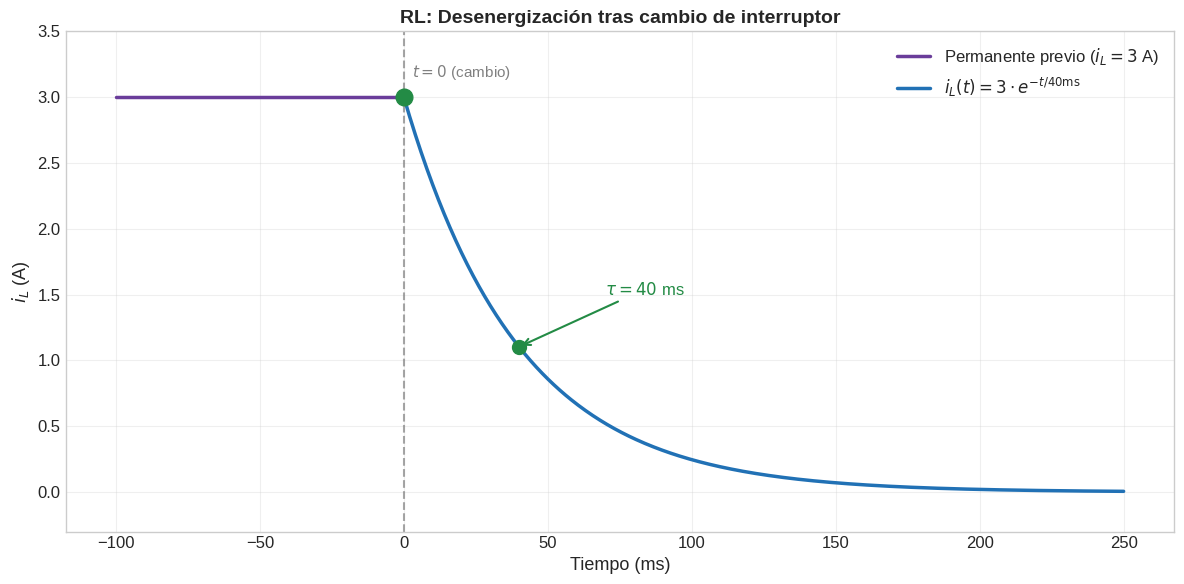

In [11]:
# Tipo 7: RL con cambio de interruptor — forma de onda
fig, ax = plt.subplots(figsize=(12, 6))

tau_ms = 40.0
t_before = np.linspace(-100, 0, 100)
t_after = np.linspace(0, 250, 500)

il_before = np.full_like(t_before, 3.0)
il_after = 3.0 * np.exp(-t_after / tau_ms)

ax.plot(t_before, il_before, color=COLOR_PERM, lw=2.5, label=r'Permanente previo ($i_L = 3$ A)')
ax.plot(t_after, il_after, color=COLOR_PRINCIPAL, lw=2.5, label=r'$i_L(t) = 3 \cdot e^{-t/40\mathrm{ms}}$')

ax.axvline(x=0, color='gray', ls='--', lw=1.5, alpha=0.7)
ax.text(3, 3.15, r'$t = 0$ (cambio)', fontsize=11, color='gray')

ax.plot(0, 3, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.plot(tau_ms, 3*np.exp(-1), 'o', color=COLOR_PUNTO, ms=10, zorder=5)
ax.annotate(f'$\\tau = {tau_ms:.0f}$ ms', xy=(tau_ms, 3*np.exp(-1)),
            xytext=(tau_ms+30, 1.5), fontsize=12, color=COLOR_PUNTO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$i_L$ (A)')
ax.set_title('RL: Desenergización tras cambio de interruptor', fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.3, 3.5)
plt.tight_layout()
plt.show()

### 7.8 Tipo 8: Cálculo de $\tau$ con Thévenin

Cuando el circuito tiene varias resistencias, la constante de tiempo requiere calcular la **resistencia de Thévenin** vista desde los terminales del elemento dinámico.

$$\boxed{\tau_{RC} = R_{Th} \cdot C} \qquad \boxed{\tau_{RL} = \frac{L}{R_{Th}}}$$

**Metodología para encontrar $R_{Th}$:**
1. **Apagar** todas las fuentes independientes: fuentes de tensión $\to$ cortocircuito, fuentes de corriente $\to$ circuito abierto
2. **Retirar** el condensador o inductor
3. **Calcular** $R_{Th}$ entre los terminales (serie-paralelo, o método de la fuente de prueba)

#### Ejercicio resuelto: Cálculo de $\tau$ con Thévenin

**Datos:** $V_S = 20$ V, $R_1 = 4\;\text{k}\Omega$, $R_2 = 12\;\text{k}\Omega$, $R_3 = 6\;\text{k}\Omega$, $C = 0.5\;\mu\text{F}$. El condensador $C$ está entre los nodos A y B. $R_1$ va de $V_S$ al nodo A, $R_2$ va del nodo A a masa, $R_3$ va del nodo A al nodo B, y B está a masa.

**Paso 1:** Apagar $V_S$ (cortocircuito):

$R_1$ queda de A a masa. Desde los terminales de $C$ (entre nodo A-$R_3$ y masa):

$$R_{Th} = R_3 + (R_1 \| R_2) = 6 + \frac{4 \times 12}{4 + 12} = 6 + 3 = 9\;\text{k}\Omega$$

**Paso 2:** Constante de tiempo:

$$\tau = R_{Th} \cdot C = 9\;\text{k}\Omega \times 0.5\;\mu\text{F} = 4.5\;\text{ms}$$

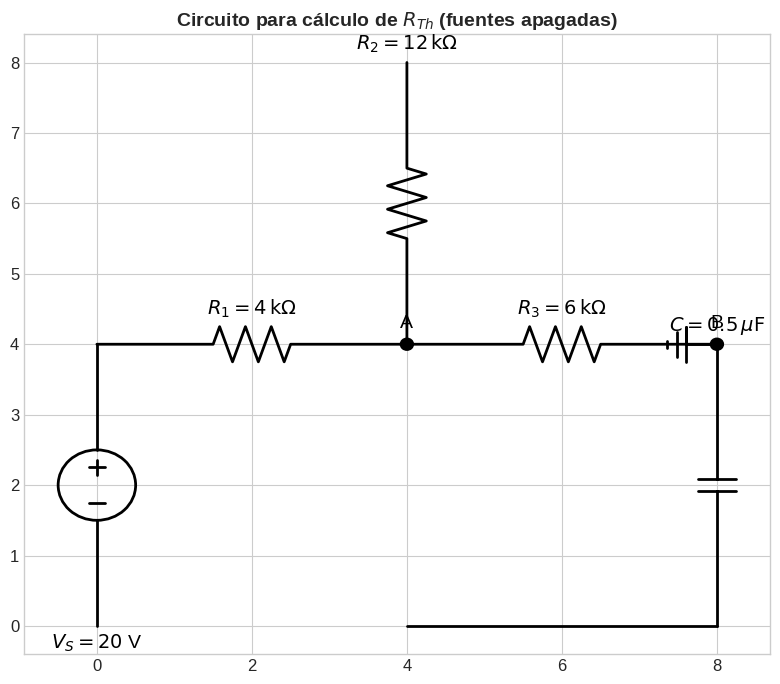

In [12]:
# Tipo 8: Circuito para cálculo de Thévenin
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title(r'Circuito para cálculo de $R_{Th}$ (fuentes apagadas)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.SourceV().up().label(r'$V_S = 20$ V', loc='left').length(4)
d += elm.Resistor().right().label(r'$R_1 = 4\,\mathrm{k\Omega}$', loc='top').length(4)
d += (nA := elm.Dot().label('A', loc='top'))
d += elm.Resistor().right().label(r'$R_3 = 6\,\mathrm{k\Omega}$', loc='top').length(4)
d += (nB := elm.Dot().label('B', loc='top'))
d += elm.Capacitor().down().label(r'$C = 0.5\,\mu\mathrm{F}$', loc='right').length(4)
d += elm.Line().left().length(4).tox(nA.start)
d += elm.Resistor().up().at(nA.start).label(r'$R_2 = 12\,\mathrm{k\Omega}$', loc='right').length(4)
d.push()
d += elm.Line().left().tox(nA.start).length(4)
d.pop()
d += elm.Ground().at(nB.start).down()
d.draw()

plt.tight_layout()
plt.show()

### 7.9 Tipo 9: Transitorio multi-etapa

El circuito sufre **dos o más cambios** en instantes distintos ($t_1$, $t_2$, ...). Cada etapa se resuelve por separado, usando el valor final de la etapa anterior como condición inicial de la siguiente.

**Metodología:**
1. **Etapa 1** ($0 < t < t_1$): resolver normalmente con $x(0^+)$, $x_1(\infty)$, $\tau_1$
2. Calcular $x(t_1^-)$ sustituyendo $t = t_1$ en la solución de la etapa 1
3. **Continuidad:** $x(t_1^+) = x(t_1^-)$
4. **Etapa 2** ($t > t_1$): resolver con $x(t_1^+)$, $x_2(\infty)$, $\tau_2$ (del nuevo circuito)

#### Ejercicio resuelto: RC con dos etapas

**Datos:** $V_S = 10$ V, $R = 2\;\text{k}\Omega$, $C = 5\;\mu\text{F}$, $v_C(0^-) = 0$ V.
- En $t = 0$: se cierra interruptor $\to$ carga del condensador
- En $t = 20\;\text{ms}$: se abre el interruptor Y se conecta otra resistencia $R_2 = 3\;\text{k}\Omega$ (descarga)

**Etapa 1** ($0 < t < 20\;\text{ms}$): Carga RC con $\tau_1 = RC = 10\;\text{ms}$

$$v_C(t) = 10(1 - e^{-t/10\text{ms}})$$

En $t = 20\;\text{ms}$: $v_C(20\;\text{ms}) = 10(1 - e^{-2}) = 10 \times 0.8647 = 8.65\;\text{V}$

**Etapa 2** ($t > 20\;\text{ms}$): Descarga a través de $R_2$ con $\tau_2 = R_2 \cdot C = 15\;\text{ms}$

$$v_C(t) = 8.65 \cdot e^{-(t - 20\text{ms})/15\text{ms}}\;\text{V} \quad (t > 20\;\text{ms})$$

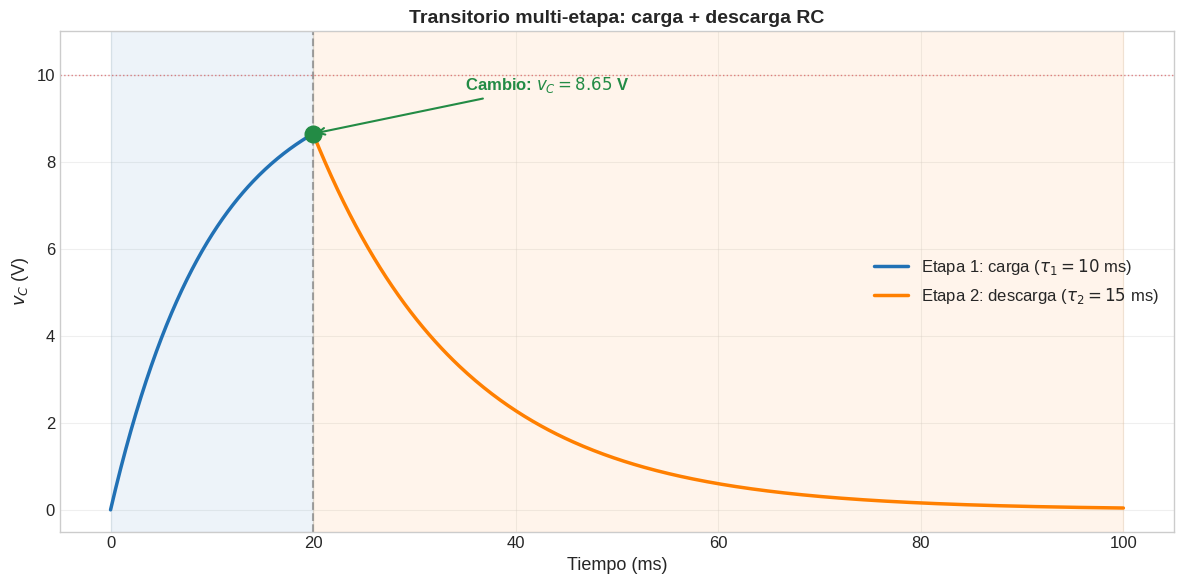

In [13]:
# Tipo 9: Transitorio multi-etapa RC
fig, ax = plt.subplots(figsize=(12, 6))

# Etapa 1: carga (0 a 20 ms)
tau1 = 10.0
t1 = np.linspace(0, 20, 200)
vc1 = 10 * (1 - np.exp(-t1 / tau1))

# Valor en t=20 ms
vc_20 = 10 * (1 - np.exp(-20 / tau1))

# Etapa 2: descarga (20 ms en adelante)
tau2 = 15.0
t2 = np.linspace(20, 100, 400)
vc2 = vc_20 * np.exp(-(t2 - 20) / tau2)

ax.plot(t1, vc1, color=COLOR_PRINCIPAL, lw=2.5, label=r'Etapa 1: carga ($\tau_1 = 10$ ms)')
ax.plot(t2, vc2, color=COLOR_TRANS, lw=2.5, label=r'Etapa 2: descarga ($\tau_2 = 15$ ms)')

# Punto de cambio
ax.plot(20, vc_20, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.annotate(f'Cambio: $v_C = {vc_20:.2f}$ V', xy=(20, vc_20),
            xytext=(35, vc_20 + 1), fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5))

ax.axvline(x=20, color='gray', ls='--', lw=1.5, alpha=0.7)
ax.axhline(y=10, color=COLOR_RECTA, ls=':', lw=1, alpha=0.5)

# Zonas
ax.axvspan(0, 20, alpha=0.08, color=COLOR_PRINCIPAL)
ax.axvspan(20, 100, alpha=0.08, color=COLOR_TRANS)

ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$v_C$ (V)')
ax.set_title('Transitorio multi-etapa: carga + descarga RC', fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 11)
plt.tight_layout()
plt.show()

### 7.10 Tipo 10: Energía en $C$/$L$ durante el transitorio

Calcular la energía almacenada y/o disipada durante un proceso transitorio.

**Fórmulas de energía almacenada:**

$$\boxed{W_C(t) = \frac{1}{2}C \cdot v_C^2(t)} \qquad \boxed{W_L(t) = \frac{1}{2}L \cdot i_L^2(t)}$$

**Energía disipada** en la resistencia (balance energético):

$$W_R = W_{\text{fuente}} - \Delta W_{\text{almacenada}}$$

**Casos típicos:**
- **Carga RC desde 0:** $W_R = \frac{1}{2}CV_S^2$ (igual a la energía almacenada)
- **Descarga RC:** $W_R = \frac{1}{2}CV_0^2$ (toda la energía se disipa)
- **Energización RL:** $W_R = \frac{1}{2}LI_0^2$ al cabo de $t \to \infty$
- **Desenergización RL:** $W_R = \frac{1}{2}LI_0^2$

#### Ejercicio resuelto: Energía durante carga RC

**Datos:** $V_S = 10$ V, $R = 1\;\text{k}\Omega$, $C = 100\;\mu\text{F}$, $v_C(0) = 0$ V

**Energía almacenada** en el condensador al final:

$$W_C = \frac{1}{2}CV_S^2 = \frac{1}{2} \times 100\;\mu\text{F} \times 10^2 = 5\;\text{mJ}$$

**Energía total suministrada** por la fuente:

$$W_{\text{fuente}} = C \cdot V_S^2 = 100\;\mu\text{F} \times 100 = 10\;\text{mJ}$$

**Energía disipada** en $R$:

$$W_R = W_{\text{fuente}} - W_C = 10 - 5 = 5\;\text{mJ}$$

**Conclusión:** Se disipa exactamente la **mitad** de la energía, independientemente del valor de $R$.

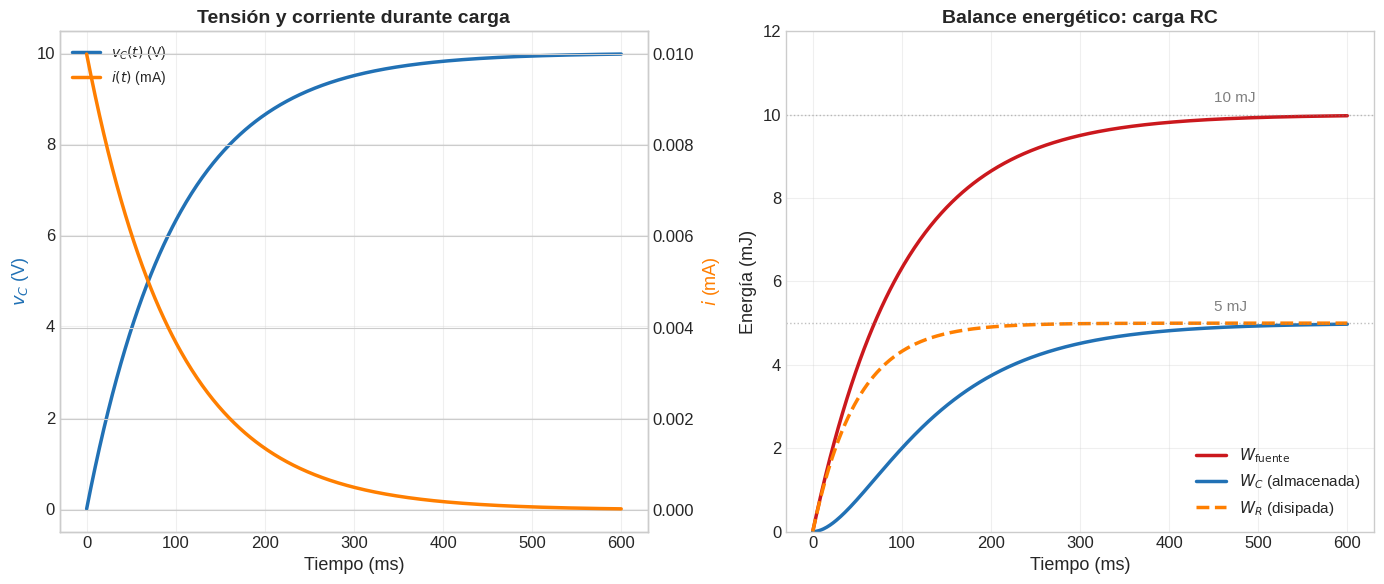

In [14]:
# Tipo 10: Energía durante carga RC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tau_ms = 100.0  # R*C = 1k * 100uF = 100 ms
t_ms = np.linspace(0, 600, 500)
VS = 10.0
C_uF = 100.0

vc = VS * (1 - np.exp(-t_ms / tau_ms))
wc = 0.5 * C_uF * 1e-6 * vc**2 * 1e3  # en mJ

# Energía de la fuente: integral de V_S * i(t) dt = C*V_S^2 * (1 - e^(-t/tau))
w_fuente = C_uF * 1e-6 * VS**2 * (1 - np.exp(-t_ms / tau_ms)) * 1e3  # en mJ
w_r = w_fuente - wc

# Panel izquierdo: tensión y corriente
ax = axes[0]
i_mA = (VS / 1e3) * np.exp(-t_ms / tau_ms)  # mA
ax.plot(t_ms, vc, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_C(t)$ (V)')
ax2 = ax.twinx()
ax2.plot(t_ms, i_mA, color=COLOR_TRANS, lw=2.5, label=r'$i(t)$ (mA)')
ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel(r'$v_C$ (V)', color=COLOR_PRINCIPAL)
ax2.set_ylabel(r'$i$ (mA)', color=COLOR_TRANS)
ax.set_title('Tensión y corriente durante carga', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
ax.grid(True, alpha=0.3)

# Panel derecho: energías
ax = axes[1]
ax.plot(t_ms, w_fuente, color=COLOR_RECTA, lw=2.5, label=r'$W_{\mathrm{fuente}}$')
ax.plot(t_ms, wc, color=COLOR_PRINCIPAL, lw=2.5, label=r'$W_C$ (almacenada)')
ax.plot(t_ms, w_r, color=COLOR_TRANS, lw=2.5, ls='--', label=r'$W_R$ (disipada)')
ax.axhline(y=5, color='gray', ls=':', lw=1, alpha=0.5)
ax.axhline(y=10, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(450, 5.3, '5 mJ', fontsize=11, color='gray')
ax.text(450, 10.3, '10 mJ', fontsize=11, color='gray')
ax.set_xlabel('Tiempo (ms)')
ax.set_ylabel('Energía (mJ)')
ax.set_title('Balance energético: carga RC', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()

### Tabla resumen del catálogo

| Tipo | Fórmula principal | Qué se calcula |
|------|-------------------|----------------|
| 1. Permanente CC | $C \to$ abierto, $L \to$ corto | Tensiones y corrientes en estado estacionario |
| 2. Condiciones iniciales | $v_C(0^+) = v_C(0^-)$, $i_L(0^+) = i_L(0^-)$ | Variables en $t = 0^+$ |
| 3. Carga RC | $\dfrac{v_C(t) = V_S(1-e^{-t/RC})}{\ }$ | Tensión del condensador en carga |
| 4. Descarga RC | $v_C(t) = V_0 \cdot e^{-t/RC}$ | Tensión del condensador en descarga |
| 5. Energización RL | $i_L(t) = \dfrac{V_S}{R}(1-e^{-tR/L})$ | Corriente del inductor en carga |
| 6. Desenergización RL | $i_L(t) = I_0 \cdot e^{-tR/L}$ | Corriente del inductor en descarga |
| 7. Cambio de interruptor | $x(\infty) + [x(0^+)-x(\infty)]e^{-t/\tau}$ | Cualquier variable tras cambio |
| 8. $\tau$ con Thévenin | $\tau = R_{Th} \cdot C$ o $L/R_{Th}$ | Constante de tiempo en circuitos complejos |
| 9. Multi-etapa | Resolver etapa por etapa | Transitorios con varios cambios |
| 10. Energía | $W_C = \frac{1}{2}Cv^2$, $W_L = \frac{1}{2}Li^2$ | Balance energético |

---

## 8. Resumen y tabla de fórmulas clave

| Fórmula clave | Uso |
|---------------|-----|
| $C \to$ circuito abierto, $L \to$ cortocircuito | **Régimen permanente CC**: eliminar derivadas |
| $v_C(0^+) = v_C(0^-)$ | **Continuidad** de tensión en condensador |
| $i_L(0^+) = i_L(0^-)$ | **Continuidad** de corriente en inductor |
| $\boxed{x(t) = x(\infty) + [x(0^+) - x(\infty)] \cdot e^{-t/\tau}}$ | **Fórmula general** de transitorio 1er orden |
| $\tau_{RC} = R_{Th} \cdot C$ | **Constante de tiempo** del circuito RC |
| $\tau_{RL} = L / R_{Th}$ | **Constante de tiempo** del circuito RL |
| $v_C(t) = V_S(1 - e^{-t/\tau})$ | **Carga RC** desde 0 V |
| $v_C(t) = V_0 \cdot e^{-t/\tau}$ | **Descarga RC** |
| $i_L(t) = I_0(1 - e^{-t/\tau})$ | **Energización RL** desde 0 A |
| $i_L(t) = I_0 \cdot e^{-t/\tau}$ | **Desenergización RL** |
| $W_C = \frac{1}{2}C v_C^2$ | **Energía** almacenada en condensador |
| $W_L = \frac{1}{2}L i_L^2$ | **Energía** almacenada en inductor |
| $x(t) = x_{\text{natural}} + x_{\text{forzada}}$ | **Descomposición** de la respuesta |
| $5\tau$ | Tiempo para alcanzar 99.3% del valor final |

### Pasos para resolver cualquier transitorio de 1er orden

1. **Encontrar $x(0^+)$**: condición inicial (continuidad + resolver circuito en $t = 0^+$)
2. **Encontrar $x(\infty)$**: régimen permanente CC ($C$ abierto, $L$ corto)
3. **Encontrar $\tau$**: $R_{Th} \cdot C$ o $L/R_{Th}$ (apagar fuentes, retirar elemento dinámico)
4. **Escribir la solución**: $x(t) = x(\infty) + [x(0^+) - x(\infty)] \cdot e^{-t/\tau}$